This is the jupyter notebook having code, plots and comments for building and evaluating linear regression model on the California Housing dataset. 

Below segment of code is used for building UI for predicting house price.

In [26]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

# Load artifacts
@st.cache_resource
def load_artifacts():
    with open('california_model.pkl', 'rb') as f:
        model = pickle.load(f)
    with open('california_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler

model, scaler = load_artifacts()

# Building UI
st.title("🏡 California Housing Predictor")
st.write("Enter the neighborhood details below:")

col1, col2 = st.columns(2)
with col1:
    med_inc = st.number_input("Median Income (in $10,000s)", value=3.5)
    house_age = st.number_input("House Age (years)", value=25.0)
    ave_rooms = st.number_input("Average Rooms per Dwelling", value=5.0)
    ave_bedrms = st.number_input("Average Bedrooms", value=1.0)
with col2:
    population = st.number_input("Block Population", value=1000.0)
    ave_occup = st.number_input("Average Occupants", value=3.0)
    latitude = st.number_input("Latitude", value=34.0)
    longitude = st.number_input("Longitude", value=-118.0)

if st.button("Predict Price", type="primary"):
    # Creating input array
    input_data = np.array([[med_inc, house_age, ave_rooms, ave_bedrms, 
                            population, ave_occup, latitude, longitude]])
    
    # Scaling and predicting
    scaled_data = scaler.transform(input_data)
    prediction = model.predict(scaled_data)[0]
    
    st.success(f"### Estimated Value: ${prediction * 100000:,.2f}")

Overwriting app.py


Loading California Housing dataset...

--- First 5 Rows of the Dataset ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Dataset Info ---
Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary statistics:
                    mean         min           max
MedInc          3.870671

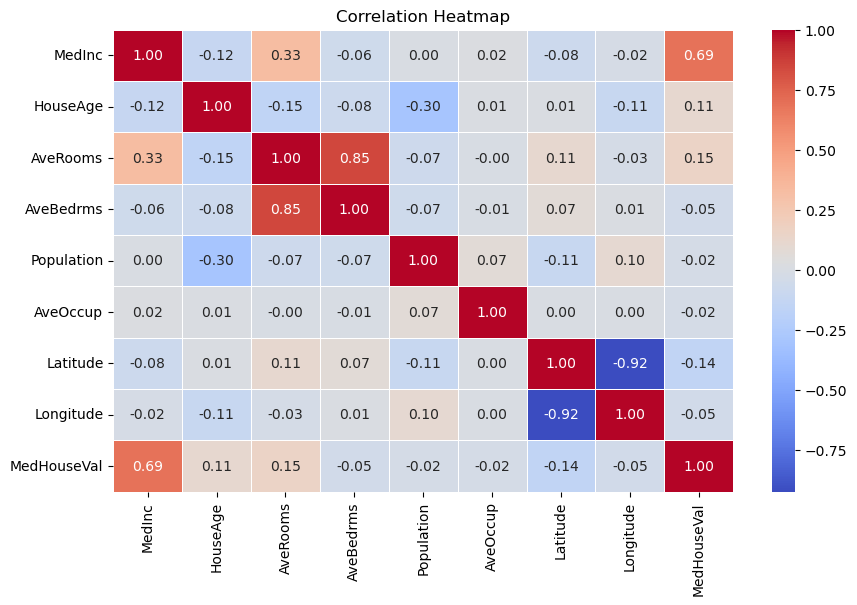

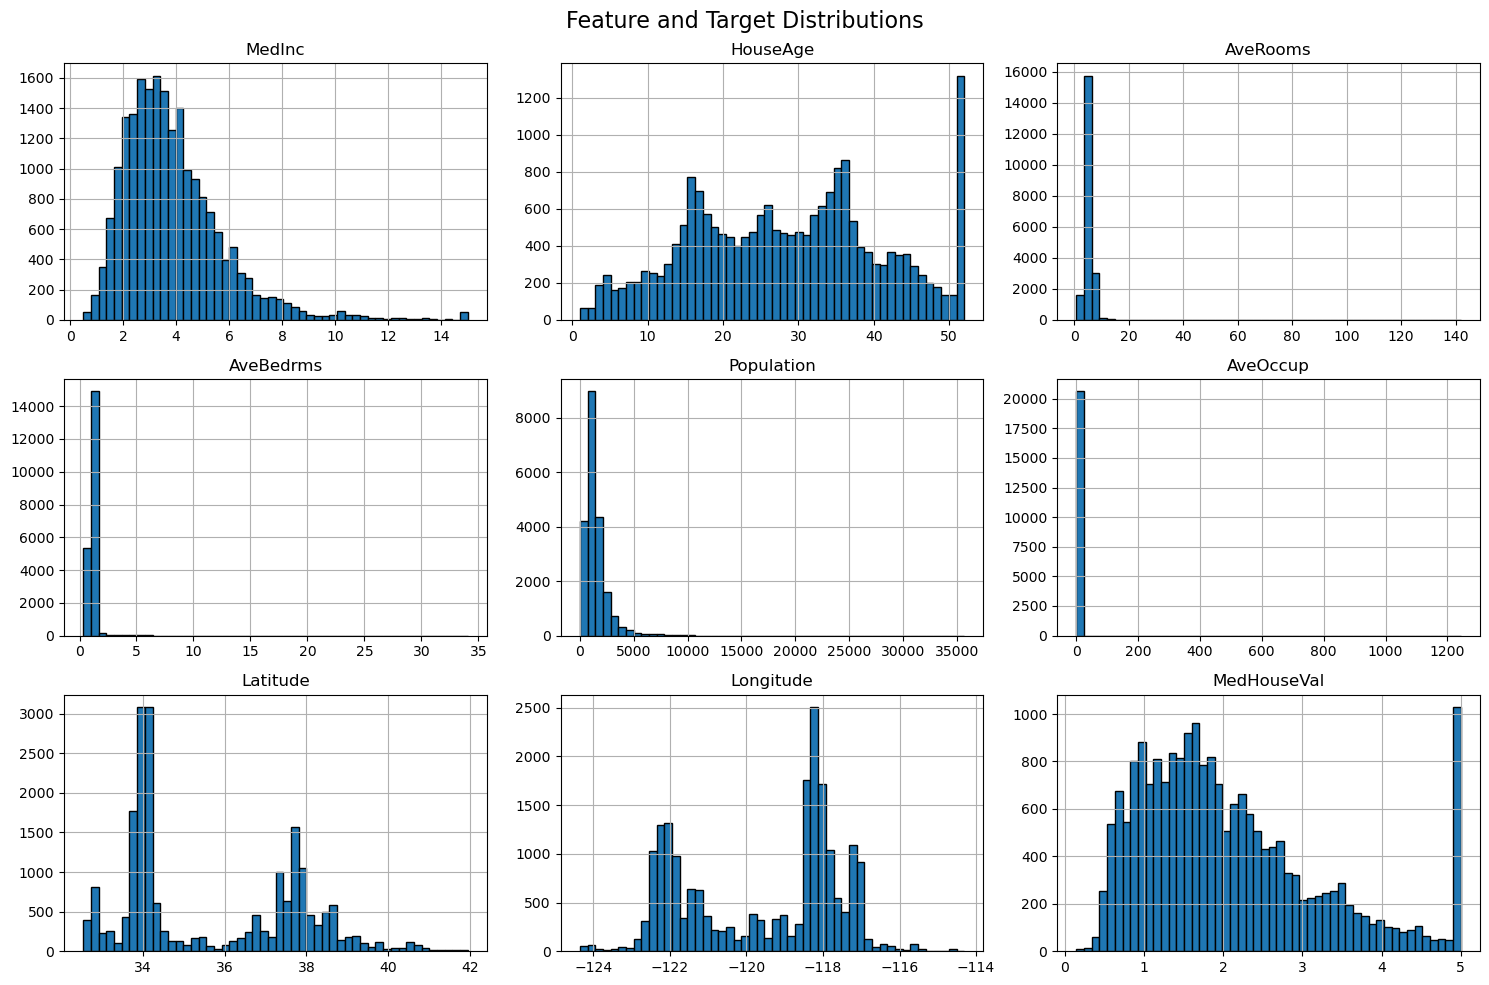

In [21]:
# BLOCK 1: Setup and EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Loading Data
print("Loading California Housing dataset...")
california = fetch_california_housing(as_frame=True)
df = california.frame
X = california.data
y = california.target

# Viewing the Data
print("\n--- First 5 Rows of the Dataset ---")
print(df.head())

# Basic Info & Missing Values
print("\n--- Dataset Info ---")
print(f"Missing values:\n{df.isnull().sum()}\n")
print(f"Summary statistics:\n{df.describe().T[['mean', 'min', 'max']]}\n")

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Feature Distributions
df.hist(bins=50, figsize=(15, 10), edgecolor='black')
plt.suptitle("Feature and Target Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
# BLOCK 2: Splitting and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Standardizing Features
scaler = StandardScaler()

# We first fit the scaler ONLY on the training data to prevent data leakage, 
# and then we transform both train and test sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature scaling complete.")

Training data shape: (16512, 8)
Testing data shape: (4128, 8)

Feature scaling complete.


In [23]:
# BLOCK 3: Model Training
from sklearn.linear_model import LinearRegression

print("Initializing Linear Regression model...")
model = LinearRegression()

print("Training the model on the scaled training data...")
model.fit(X_train_scaled, y_train)

print("Model training complete!")

Initializing Linear Regression model...
Training the model on the scaled training data...
Model training complete!


--- Model Evaluation ---
MAE:  0.5332
RMSE: 0.7456
R2:   0.5758



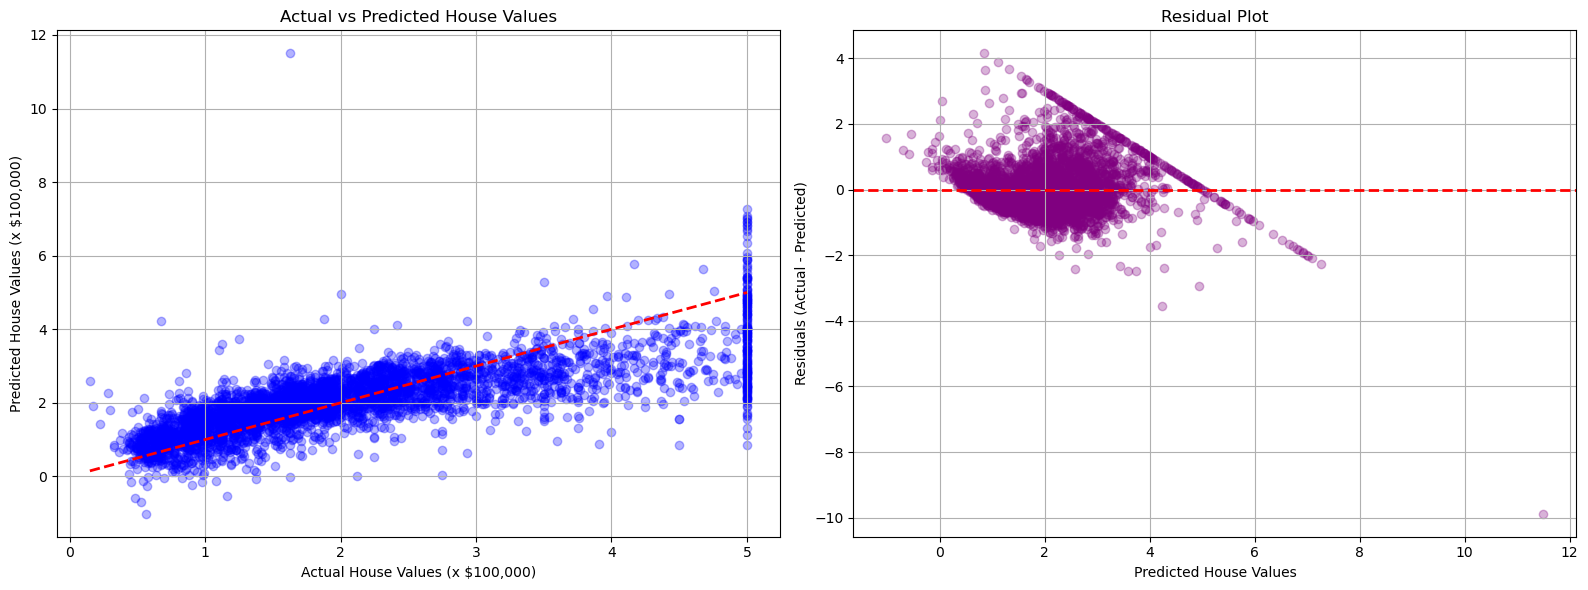

In [24]:
# BLOCK 4: Evaluation and Plotting
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generating Predictions
y_pred = model.predict(X_test_scaled)

# Calculating Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}\n")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='blue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
axes[0].set_xlabel("Actual House Values (x $100,000)")
axes[0].set_ylabel("Predicted House Values (x $100,000)")
axes[0].set_title("Actual vs Predicted House Values")
axes[0].grid(True)

# Plot B: Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted House Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [25]:
import pickle

# Saving the trained model
with open('california_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Saving the scaler
with open('california_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully to your current directory!")

Model and scaler saved successfully to your current directory!


To run the prediction on new inputs we just have to run the command 'streamlit run app.py' into the jupyter lab terminal into the same folder in which 'task1_ml_linear_regression.ipynb' notebook is present.